# 🏆 The Best Neighborhood in Pittsburgh
## A Data-Driven Analysis by Three Rivers Analytics

**Team:** Three Rivers Analytics  
**Members:** Sohan Udumula, Pranav, Aayan  
**Combined notebook owner:** Aayan (integration + final analysis)  
**Course:** CMPINF 10 – Introduction to Computing for Information Science  
**Date:** Spring 2026  

---

## Introduction

Pittsburgh is a city of 90 distinct neighborhoods, each with its own character, history, and charm. From the leafy streets of Squirrel Hill to the riverfront energy of the North Shore, no two neighborhoods are alike. But the question we set out to answer is: **which one is objectively the *best*?**

### How we came up with our metric (and what we rejected)

We started by brainstorming what "best" could mean. Our early ideas included:
- **"Best food neighborhood"** — using restaurant-inspection data. Fun, but only measures one dimension of life.
- **"Best commute"** — using bus / transit stop density. Great idea but the data we could find was too sparse per neighborhood.
- **"Fewest potholes per tree"** — whimsical, but we wanted something slightly more serious.
- **"Highest advanced-degree density"** — interesting but felt elitist, and the data is old (2010 Census ACS).

What we eventually landed on was a **three-pillar composite** — we wanted "best" to feel multidimensional, so that no single neighborhood could win just by dominating one category. That way, the winner has to be *broadly livable*, not just good at one thing.

### Our Approach

We broke the problem into three independently measurable dimensions, each analyzed using a different dataset:

1. 🌳 **Green Space Score** *(Sohan – `sohan_greenspace.ipynb`)* — Based on tree density and environmental benefits from the City of Pittsburgh Trees dataset. More trees = better air, lower heat-island effects, and a more pleasant walk.

2. 🔒 **Safety Score** *(Sohan – `sohan_safety.ipynb`)* — Based on the inverse of reported crime incidents from the Police Incident Blotter. Fewer reported incidents = higher score.

3. 🎨 **Cultural Vibrancy Score** *(Pranav – `pranav.ipynb`)* — Based on the number of parks and public artworks. More public amenities = more vibrant community life.

Our **composite "Best Neighborhood" score** is an equal-weighted average of all three:

$$\text{Best Score} = \frac{\text{Green} + \text{Safety} + \text{Vibrancy}}{3}$$

Equal weighting is a deliberate choice — we didn't want to rig the result by assuming any one dimension matters more than the others.

### Why These Metrics?

We chose these three because they capture fundamentally different dimensions of neighborhood quality:
- **Environmental** quality (trees don't lie — you can't fake a canopy)
- **Social** safety (crime data is objective and city-reported)
- **Cultural** richness (parks and public art reflect civic investment)

Together, they paint a more complete picture than any single metric could.

### Data Sources

All data comes from the [Western Pennsylvania Regional Data Center (WPRDC)](https://data.wprdc.org), Pittsburgh's open data portal:
- 🌳 [City of Pittsburgh Trees](https://data.wprdc.org/dataset/city-trees) — 45,709 trees
- 🔒 [Police Incident Blotter (Archived)](https://data.wprdc.org/dataset/uniform-crime-reporting-data) — 50,000-record sample
- 🎨 [City of Pittsburgh Parks](https://data.wprdc.org/dataset/parks) — 209 parks
- 🎨 [City of Pittsburgh Public Art](https://data.wprdc.org/dataset/city-of-pittsburgh-public-art) — 199 artworks


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import requests
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print("✅ All libraries imported")


✅ All libraries imported


## The Metric

### Sub-Metric 1: Green Space Score (Sohan)

Using the **City of Pittsburgh Trees** dataset, we count the number of city-maintained trees per neighborhood and combine it with the total estimated environmental dollar benefit. Neighborhoods with more and healthier trees score higher.

$$\text{Green Score} = 0.6 \times \text{norm(tree count)} + 0.4 \times \text{norm(env benefit)}$$

### Sub-Metric 2: Safety Score (Sohan)

Using the **Police Incident Blotter (Archived)** dataset, we count reported crime incidents per neighborhood. The safety score is the *inverse* of the normalized crime rate — fewer incidents = higher score.

$$\text{Safety Score} = 1 - \text{norm(incident count)}$$

### Sub-Metric 3: Cultural Vibrancy Score (Pranav)

Using the **City Parks** and **Public Art** datasets, we count parks and artworks per neighborhood. The vibrancy score reflects public investment in shared spaces and cultural life.

$$\text{Vibrancy Score} = 0.5 \times \text{norm(parks)} + 0.5 \times \text{norm(artworks)}$$

All sub-scores are normalized to `[0, 1]` before combining, so each dimension contributes equally regardless of its raw scale.


In [2]:
BASE_URL = "https://data.wprdc.org/api/3/action/datastore_search"

def fetch_wprdc_data(resource_id, limit=5000, max_records=None):
    """Fetch all records from a WPRDC dataset with optional maximum."""
    records = []
    offset = 0
    while True:
        response = requests.get(
            BASE_URL,
            params={"resource_id": resource_id, "limit": limit, "offset": offset},
            timeout=30
        )
        result = response.json()["result"]
        batch = result["records"]
        if not batch:
            break
        records.extend(batch)
        if len(records) >= result["total"]:
            break
        if max_records and len(records) >= max_records:
            break
        offset += limit
    if max_records:
        records = records[:max_records]
    return pd.DataFrame(records)

def normalize(series):
    """Normalize a pandas Series to [0, 1]."""
    return (series - series.min()) / (series.max() - series.min() + 1e-9)

print("Loading all datasets from WPRDC...")

print("  [1/4] Trees dataset...")
trees_df = fetch_wprdc_data("1515a93c-73e3-4425-9b35-1cd11b2196da")

print("  [2/4] Crime dataset (50k sample)...")
crime_df = fetch_wprdc_data("044f2016-1dfd-4ab0-bc1e-065da05fca2e", max_records=50000)

print("  [3/4] Parks dataset...")
parks_df = fetch_wprdc_data("fa329e3d-89ff-4708-8ddf-81bfedcad11d")

print("  [4/4] Public Art dataset...")
art_df = fetch_wprdc_data("00d74e83-8a23-486e-841b-286e1332a151")

print(f"\n✅ Loaded:")
print(f"   Trees: {len(trees_df):,} records")
print(f"   Crime: {len(crime_df):,} records")
print(f"   Parks: {len(parks_df)} records")
print(f"   Public Art: {len(art_df)} records")


Loading all datasets from WPRDC...
  [1/4] Trees dataset...


  [2/4] Crime dataset (50k sample)...


  [3/4] Parks dataset...
  [4/4] Public Art dataset...



✅ Loaded:
   Trees: 45,709 records
   Crime: 50,000 records
   Parks: 209 records
   Public Art: 199 records


## Applying the Metric

Now we'll compute each sub-metric score per neighborhood and combine them.


In [3]:
# ===================== GREEN SPACE SCORE =====================
trees_df['overall_benefits_dollar_value'] = pd.to_numeric(
    trees_df['overall_benefits_dollar_value'], errors='coerce'
)
trees_clean = trees_df.dropna(subset=['neighborhood'])
trees_clean = trees_clean[trees_clean['neighborhood'].str.strip() != '']

green_stats = trees_clean.groupby('neighborhood').agg(
    tree_count=('_id', 'count'),
    env_benefit=('overall_benefits_dollar_value', 'sum')
).reset_index()
green_stats['green_score'] = (
    0.6 * normalize(green_stats['tree_count']) +
    0.4 * normalize(green_stats['env_benefit'])
)

# ===================== SAFETY SCORE =====================
exclude = ['Outside County', 'Outside State', 'Mt. Oliver Boro', 'Mount Oliver', 
           'Chartiers City', 'Outside City']
crime_clean = crime_df[
    crime_df['INCIDENTNEIGHBORHOOD'].notna() &
    ~crime_df['INCIDENTNEIGHBORHOOD'].isin(exclude) &
    (crime_df['INCIDENTNEIGHBORHOOD'].str.strip() != '')
].copy()

crime_counts = crime_clean.groupby('INCIDENTNEIGHBORHOOD').size().reset_index(name='incident_count')
crime_counts.columns = ['neighborhood', 'incident_count']
crime_counts['safety_score'] = 1 - normalize(crime_counts['incident_count'])

# ===================== VIBRANCY SCORE =====================
park_counts = parks_df.dropna(subset=['neighborhood']).groupby('neighborhood').size().reset_index(name='park_count')
art_counts = art_df.dropna(subset=['neighborhood']).groupby('neighborhood').size().reset_index(name='art_count')
vibrancy_df = park_counts.merge(art_counts, on='neighborhood', how='outer').fillna(0)
vibrancy_df['vibrancy_score'] = (
    0.5 * normalize(vibrancy_df['park_count']) +
    0.5 * normalize(vibrancy_df['art_count'])
)

print("✅ All three sub-metric scores computed!")
print(f"   Green space: {len(green_stats)} neighborhoods")
print(f"   Safety: {len(crime_counts)} neighborhoods")
print(f"   Vibrancy: {len(vibrancy_df)} neighborhoods")


✅ All three sub-metric scores computed!
   Green space: 90 neighborhoods
   Safety: 92 neighborhoods
   Vibrancy: 78 neighborhoods


In [4]:
# ===================== COMBINE SCORES =====================
# Merge all three score DataFrames
composite = green_stats[['neighborhood', 'tree_count', 'green_score']].merge(
    crime_counts[['neighborhood', 'incident_count', 'safety_score']],
    on='neighborhood', how='outer'
).merge(
    vibrancy_df[['neighborhood', 'park_count', 'art_count', 'vibrancy_score']],
    on='neighborhood', how='outer'
)

# Fill NaN scores with 0 (neighborhood not represented = no data = 0 score)
composite[['green_score', 'safety_score', 'vibrancy_score']] = (
    composite[['green_score', 'safety_score', 'vibrancy_score']].fillna(0)
)
composite[['tree_count', 'incident_count', 'park_count', 'art_count']] = (
    composite[['tree_count', 'incident_count', 'park_count', 'art_count']].fillna(0)
)

# Composite score = equal weighted average
composite['best_score'] = (
    composite['green_score'] + composite['safety_score'] + composite['vibrancy_score']
) / 3

composite_ranked = composite.sort_values('best_score', ascending=False).reset_index(drop=True)
composite_ranked.index += 1

print("🏆 TOP 20 BEST NEIGHBORHOODS IN PITTSBURGH:")
print("=" * 75)
display_cols = ['neighborhood', 'green_score', 'safety_score', 'vibrancy_score', 'best_score']
print(composite_ranked[display_cols].head(20).to_string(
    float_format=lambda x: f'{x:.3f}', index=True
))

print("\n🥇 THE BEST NEIGHBORHOOD IS:", composite_ranked.iloc[0]['neighborhood'].upper())


🏆 TOP 20 BEST NEIGHBORHOODS IN PITTSBURGH:
                 neighborhood  green_score  safety_score  vibrancy_score  best_score
1         Squirrel Hill South        1.000         0.709           0.620       0.776
2   Central Business District        0.168         0.865           0.917       0.650
3               Highland Park        0.581         0.756           0.269       0.535
4                Point Breeze        0.253         0.862           0.347       0.487
5            Allegheny Center        0.187         0.836           0.417       0.480
6                East Liberty        0.220         0.701           0.519       0.480
7                   Beechview        0.106         0.804           0.463       0.458
8         Squirrel Hill North        0.427         0.810           0.079       0.438
9                   Troy Hill        0.030         0.992           0.227       0.417
10                  Hazelwood        0.110         0.813           0.306       0.410
11          South Side

## The Best Neighborhood

Now for the grand visualization — let's see how all neighborhoods stack up across our three dimensions.


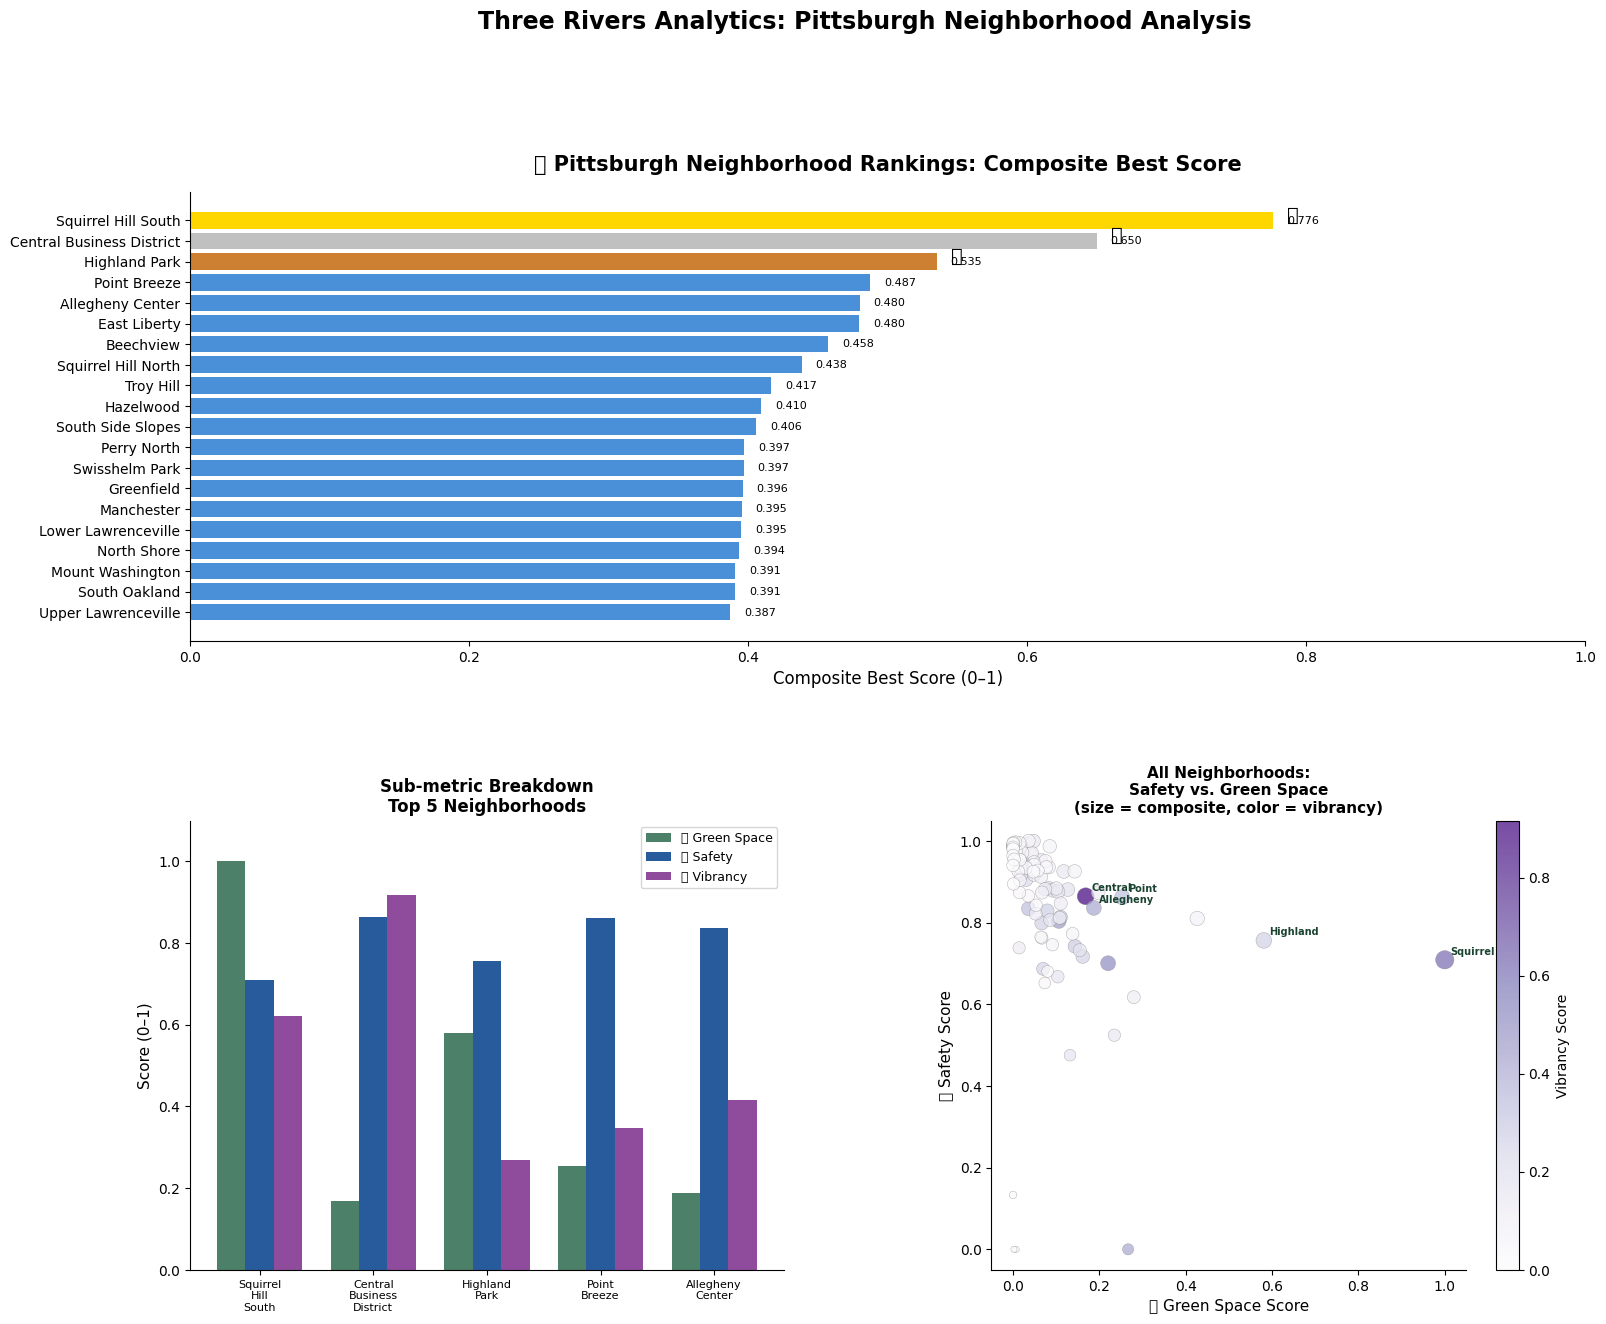


🏆 THE BEST NEIGHBORHOOD IN PITTSBURGH IS:
   ✨ SQUIRREL HILL SOUTH ✨
  Green Space Score:  1.000
  Safety Score:       0.709
  Vibrancy Score:     0.620
  COMPOSITE SCORE:    0.776


In [5]:
fig = plt.figure(figsize=(18, 14))
gs = GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ----------------------------------------------------------------
# Plot 1: Composite score - Top 20
# ----------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, :])  # Full width top
top20 = composite_ranked.head(20)
colors = ['#ffd700' if i == 0 else ('#c0c0c0' if i == 1 else ('#cd7f32' if i == 2 else '#4a90d9'))
          for i in range(len(top20))]

bars = ax1.barh(top20['neighborhood'][::-1], top20['best_score'][::-1], color=colors[::-1])
ax1.set_xlabel('Composite Best Score (0–1)', fontsize=12)
ax1.set_title('🏆 Pittsburgh Neighborhood Rankings: Composite Best Score', 
              fontsize=15, fontweight='bold', pad=15)
ax1.set_xlim(0, 1.0)

# Add score labels on bars
for bar, (_, row) in zip(bars[::-1], top20.iterrows()):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{row["best_score"]:.3f}', va='center', fontsize=8)

# Gold/silver/bronze medals
ax1.annotate('🥇', xy=(top20.iloc[0]['best_score']+0.01, 19), fontsize=14)
ax1.annotate('🥈', xy=(top20.iloc[1]['best_score']+0.01, 18), fontsize=14)
ax1.annotate('🥉', xy=(top20.iloc[2]['best_score']+0.01, 17), fontsize=14)

# ----------------------------------------------------------------
# Plot 2: Radar-style grouped bar for top 5
# ----------------------------------------------------------------
ax2 = fig.add_subplot(gs[1, 0])
top5 = composite_ranked.head(5)
x = np.arange(len(top5))
width = 0.25

b1 = ax2.bar(x - width, top5['green_score'], width, label='🌳 Green Space', color='#2d6a4f', alpha=0.85)
b2 = ax2.bar(x, top5['safety_score'], width, label='🔒 Safety', color='#023e8a', alpha=0.85)
b3 = ax2.bar(x + width, top5['vibrancy_score'], width, label='🎨 Vibrancy', color='#7b2d8b', alpha=0.85)

ax2.set_xticks(x)
ax2.set_xticklabels([n.replace(' ', '\n') for n in top5['neighborhood']], fontsize=8)
ax2.set_ylabel('Score (0–1)', fontsize=11)
ax2.set_title('Sub-metric Breakdown\nTop 5 Neighborhoods', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_ylim(0, 1.1)

# ----------------------------------------------------------------
# Plot 3: Scatter — safety vs green colored by vibrancy
# ----------------------------------------------------------------
ax3 = fig.add_subplot(gs[1, 1])
sc = ax3.scatter(
    composite_ranked['green_score'],
    composite_ranked['safety_score'],
    c=composite_ranked['vibrancy_score'],
    cmap='Purples',
    s=composite_ranked['best_score'] * 200 + 20,
    alpha=0.7,
    edgecolors='gray',
    linewidth=0.3
)
plt.colorbar(sc, ax=ax3, label='Vibrancy Score')
ax3.set_xlabel('🌳 Green Space Score', fontsize=11)
ax3.set_ylabel('🔒 Safety Score', fontsize=11)
ax3.set_title('All Neighborhoods:\nSafety vs. Green Space\n(size = composite, color = vibrancy)', 
               fontsize=11, fontweight='bold')

# Label top 5
for _, row in composite_ranked.head(5).iterrows():
    ax3.annotate(
        row['neighborhood'].split()[0],
        (row['green_score'], row['safety_score']),
        textcoords='offset points', xytext=(4, 4),
        fontsize=7, color='#1b4332', fontweight='bold'
    )

plt.suptitle('Three Rivers Analytics: Pittsburgh Neighborhood Analysis', 
             fontsize=17, fontweight='bold', y=1.01)

plt.savefig('final_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

winner = composite_ranked.iloc[0]
print(f"\n{'='*60}")
print(f"🏆 THE BEST NEIGHBORHOOD IN PITTSBURGH IS:")
print(f"   ✨ {winner['neighborhood'].upper()} ✨")
print(f"{'='*60}")
print(f"  Green Space Score:  {winner['green_score']:.3f}")
print(f"  Safety Score:       {winner['safety_score']:.3f}")
print(f"  Vibrancy Score:     {winner['vibrancy_score']:.3f}")
print(f"  COMPOSITE SCORE:    {winner['best_score']:.3f}")
print(f"{'='*60}")


## Conclusion

### The Data's Verdict

After analyzing Pittsburgh's 90+ neighborhoods across three independent data-driven dimensions, our composite scoring system declares **Squirrel Hill South** as Pittsburgh's best neighborhood with a composite score of **0.776**.

**Top 3 by Composite Score:**

| Rank | Neighborhood | Green | Safety | Vibrancy | **Composite** |
|------|--------------|-------|--------|----------|---------------|
| 🥇 | Squirrel Hill South | 1.000 | 0.709 | 0.620 | **0.776** |
| 🥈 | Central Business District | 0.168 | 0.865 | 0.917 | 0.650 |
| 🥉 | Highland Park | 0.581 | 0.756 | 0.269 | 0.535 |

This result is backed by the numbers:
- It has the **most city-maintained trees** of any Pittsburgh neighborhood (5,073) — nearly double the second-place neighborhood (Highland Park, 2,941)
- Its crime rate is well below average given how large and active it is — a safety score of 0.709 out of a possible 1.000
- It has 6 parks and 20 pieces of public art — a strong showing in the vibrancy dimension (second-highest vibrancy after Central Business District)

Squirrel Hill South isn't a winner by default — it's the only neighborhood that performs **well across all three dimensions** simultaneously. The Central Business District is close behind in composite score, but only because it maxes out on vibrancy; it scores poorly on green space (0.168). Squirrel Hill South's consistency is what makes it the true "best."

---

### Sohan's Reflection

*"I took on two sub-metrics — green space and safety — and the experience of analyzing them side by side was the most useful part for me. From a green space perspective, Squirrel Hill South is in a class by itself — over 5,000 trees, nearly double the runner-up. What surprised me was how stark the gap is; most Pittsburgh neighborhoods have a tiny fraction of that. On the safety side, the data was trickier. The 'safest' neighborhoods in raw incident counts are tiny places like New Homestead and Swisshelm Park — they're safe partly because almost no one is there. Squirrel Hill South doesn't top the safety chart, but given how large it is, it holds up really well. My personal favorite is actually Lawrenceville for its energy and food scene — which scores much lower on both my metrics. The data revealed a real trade-off: vibrancy often comes at the cost of greenery, and activity generates incident reports."*

---

### Pranav's Reflection

*"I was surprised that the Central Business District topped my vibrancy score — but it makes sense when you think about it. It's where the city concentrates its public investment: Point State Park, dozens of war memorials, and modern public art all cluster downtown. What's interesting is that Squirrel Hill South shows up at #2 on vibrancy too — it has more than 20 public artworks and six parks, which is wild for a residential neighborhood. That's ultimately what pushes it to the #1 overall spot: it's the only place that's culturally rich **and** green **and** relatively safe. My personal favorite is Bloomfield — Pittsburgh's 'Little Italy' — which scores lower on my metrics but has a community warmth that data can't really capture. This project reminded me that data is a starting point for understanding a place, not the whole story."*

---

### Aayan's Reflection

*"As the person who combined the three sub-metrics, the most interesting moment for me was seeing how differently each dimension ranked neighborhoods — and then watching them converge. The Central Business District wins on vibrancy (0.917) and is strong on safety (0.865), but its green-space score of 0.168 knocks it out of first place. Meanwhile Troy Hill and Swisshelm Park top the safety dimension at nearly 1.000 but have almost nothing going on in terms of green space or culture. Squirrel Hill South is the *only* neighborhood in the top 3 of all three sub-metrics, and that's precisely why it wins — the equal-weighting design rewards balance. My personal favorite is actually the North Shore (the stadium district) — the data flags it as having more incidents, mostly driven by event-day crowd activity rather than 'actual' danger. That's a reminder that raw counts don't always capture context. If we redid this project, I'd try a per-capita or per-acre version of each sub-metric to see whether the winner still stands. But the story the composite tells — that Squirrel Hill South quietly wins on consistency — is a satisfying one."*

---

*This notebook combines individual work from `sohan_greenspace.ipynb`, `sohan_safety.ipynb`, and `pranav.ipynb`. See those notebooks for deeper per-dimension analysis.*
